<a href="https://colab.research.google.com/github/mpily/Community_Matrices/blob/main/Community_Matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
from scipy.linalg import solve_continuous_lyapunov
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon

### Data Cleaning: Handling `SpeciesCover` and Null Values

The `SpeciesCover` column contains non-numeric values (e.g., 'R'), which prevent aggregation. The following steps will:
1. Replace 'R' values with `np.nan`.
2. Convert the `SpeciesCover` column to a numeric data type.
3. Fill any `NaN` values (including those from 'R' and original missing data) with 0.

First we shall split the data into test data and train data. For this application, we shall use $30$% of the sites as test data and $70$% as the train data. The train data shall be used to generate the interaction matrix and using this Matrix we shall make predictions about the underlying structure of the $30$% of sites.

In [14]:


# Load the Excel file into a pandas DataFrame, specifying the sheet name
excel_file_path = '/content/Fynbos Hectare Finescale Survey_v1_final.xlsx'
df = pd.read_excel(excel_file_path, sheet_name='Plot Species Data')

# Display the first 5 rows to understand the data structure
display(df.head())

,PlotID,Species,MaxHeight,SpeciesCover,DriedHeight
0,Y01X01,Agathosma cerefolium,30,8,No
1,Y01X01,Aspalathus laricifolia subsp. laricifolia,25,3,No
2,Y01X01,Babiana villosula,10,1,No
3,Y01X01,Berkheya herbacea,20,1,No
4,Y01X01,Centella glabrata var. glabrata,10,1,No


In [15]:
# Replace 'R' with NaN in 'SpeciesCover' column
df['SpeciesCover'] = df['SpeciesCover'].replace('R', np.nan)

# Convert 'SpeciesCover' to numeric, coercing errors to NaN
df['SpeciesCover'] = pd.to_numeric(df['SpeciesCover'], errors='coerce')

# Fill any remaining NaN values in 'SpeciesCover' with 0
df['SpeciesCover'] = df['SpeciesCover'].fillna(0)

# Verify the changes by checking data types and a sample of the cleaned column
print("Data type of 'SpeciesCover' after cleaning:", df['SpeciesCover'].dtype)
print("First 5 rows of cleaned 'SpeciesCover' column:")
display(df['SpeciesCover'].head())

Data type of 'SpeciesCover' after cleaning: float64
First 5 rows of cleaned 'SpeciesCover' column:


,SpeciesCover
0,8.0
1,3.0
2,1.0
3,1.0
4,1.0


In [16]:


# Get unique PlotIDs
unique_plot_ids = df['PlotID'].unique()

# Split PlotIDs into training and testing sets
train_plot_ids, test_plot_ids = train_test_split(unique_plot_ids, test_size=0.3, random_state=42)

# Create training and testing DataFrames
df_train = df[df['PlotID'].isin(train_plot_ids)].copy()
df_test = df[df['PlotID'].isin(test_plot_ids)].copy()

print(f"Original DataFrame size: {len(df)} rows")
print(f"Training DataFrame size: {len(df_train)} rows (covering {len(train_plot_ids)} unique plots)")
print(f"Test DataFrame size: {len(df_test)} rows (covering {len(test_plot_ids)} unique plots)")

display(df_train.head())

Original DataFrame size: 56897 rows
Training DataFrame size: 39799 rows (covering 1750 unique plots)
Test DataFrame size: 17098 rows (covering 750 unique plots)


,PlotID,Species,MaxHeight,SpeciesCover,DriedHeight
0,Y01X01,Agathosma cerefolium,30,8.0,No
1,Y01X01,Aspalathus laricifolia subsp. laricifolia,25,3.0,No
2,Y01X01,Babiana villosula,10,1.0,No
3,Y01X01,Berkheya herbacea,20,1.0,No
4,Y01X01,Centella glabrata var. glabrata,10,1.0,No


Some Helper functions to be used to get the $\mathbf{B}$ matrix and species abundance including:


1.   Lyapunov inverse
2.   Lemke's algorithm




In [6]:


def lyapunov_inverse_symmetric(Sigma, D):
    """
    Recover A_sym from the static Lyapunov equation A*Sigma + Sigma*A^T = Q
    under the assumption that A is symmetric.
    """
    A_sym = solve_continuous_lyapunov(Sigma, D)

    return (A_sym+ A_sym.T)/2


In [7]:


def getBMatrix(Covariance,Community,sigma):
  stable_sites = 0
  unstable_sites = 0
  species_names = Community.columns
  # Create a B_Matrix with 0 values
  b_matrix = pd.DataFrame(
    np.zeros((len(species_names), len(species_names))),
    index=species_names,
    columns=species_names
  )
  freq_count_matrix = pd.DataFrame(
      np.zeros((len(species_names), len(species_names))),
      index=species_names,
      columns=species_names
  )
  for site_id, site_row in Community.iterrows():
    species = site_row[site_row > 0].index.to_list()
    abundance_estimate = site_row[site_row > 0]

    # Create a temporary b_matrix for the species present in this site
    num_species_in_site = len(species)
    # Skip if no species present
    if num_species_in_site == 0:
      print(f"Site {site_id}: No species present, skipping B matrix calculation.")
      continue

    temp_cov_matrix = pd.DataFrame(
        np.zeros((num_species_in_site, num_species_in_site)),
        index=species,
        columns=species
    )
    temp_B_matrix = pd.DataFrame(
        np.zeros((num_species_in_site, num_species_in_site)),
        index=species,
        columns=species
    )

    d_matrix = pd.DataFrame(
        np.zeros((num_species_in_site, num_species_in_site)),
        index=species,
        columns=species
    )

    #populate D matrix and Sigma matrix for Lyapunov function

    for plant_1 in species:
      d_matrix.loc[plant_1,plant_1] = abundance_estimate[plant_1]**2
      for plant_2 in species:
        # Ensure we are not dividing by zero if sigma is 0
        if sigma == 0:
            temp_cov_matrix.loc[plant_1,plant_2] = Covariance.loc[plant_1, plant_2]
        else:
            temp_cov_matrix.loc[plant_1,plant_2] = Covariance.loc[plant_1, plant_2]/(sigma**2)

    try:
        J = lyapunov_inverse_symmetric(temp_cov_matrix.values, d_matrix.values)
        # Convert J back to DataFrame with proper index/columns for easier handling
        eigenvals = np.linalg.eigvals(J)
        is_positive_definite = np.all(eigenvals > 0)
        if not is_positive_definite:
            print(f"Site {site_id}: J is not positive definite.")
            unstable_sites += 1
            continue
        stable_sites += 1
        J = pd.DataFrame(J, index=species, columns=species)
    except np.linalg.LinAlgError as e:
        print(f"Site {site_id}: LinAlgError in lyapunov_inverse_symmetric: {e}. Skipping site.")
        continue
    except ValueError as e:
        print(f"Site {site_id}: ValueError in lyapunov_inverse_symmetric: {e}. Skipping site.")
        continue

    for plant_1 in species:
      for plant_2 in species:
        temp_B_matrix.loc[plant_1,plant_2] = J.loc[plant_1,plant_2]/(abundance_estimate.loc[plant_1])


    # Check for positive definiteness
    if num_species_in_site > 0:
        for plant_1 in species:
          for plant_2 in species:
            b_matrix.loc[plant_1,plant_2] += temp_B_matrix.loc[plant_1,plant_2]
            freq_count_matrix.loc[plant_1,plant_2] += 1

    else:
        print(f"Site {site_id}: temp_B_matrix is trivially positive definite (empty matrix).")

  for plant_1 in species_names:
    for plant_2 in species_names:
      if freq_count_matrix.loc[plant_1,plant_2] == 0:
        continue
      else:
        b_matrix.loc[plant_1,plant_2] = b_matrix.loc[plant_1,plant_2]/freq_count_matrix.loc[plant_1,plant_2]

  print(f"Stable sites: {stable_sites}")
  print(f"Unstable sites: {unstable_sites}")
  return b_matrix



In [8]:
def lemke_lcp(M, q, d=None, max_iterations=1000, tol=1e-10):
    """
    Solve LCP(q, M) by Lemke's algorithm with Bland's rule for tie-breaking.

    Args:
        M: (n, n) array.
        q: (n,) array.
        d: (n,) positive covering vector. Defaults to ones.
        max_iterations: pivot cap.
        tol: numerical tolerance for sign / zero comparisons.

    Returns:
        z (n-vector) solving the LCP, or None if a secondary ray is hit
        (LCP has no solution reachable by Lemke's path, e.g. M not copositive-plus).
    """
    M = np.asarray(M, dtype=float)
    q = np.asarray(q, dtype=float)
    n = len(q)

    # Trivial case: q >= 0 means z = 0, w = q already solves it.
    if np.all(q >= -tol):
        return np.zeros(n)

    if d is None:
        d = np.ones(n)
    else:
        d = np.asarray(d, dtype=float)
        if np.any(d <= 0):
            raise ValueError("Covering vector d must be strictly positive.")

    # Variable indexing convention:
    #   0 .. n-1       -> w_0 .. w_{n-1}
    #   n .. 2n-1      -> z_0 .. z_{n-1}
    #   2n             -> z0 (artificial)
    Z0 = 2 * n

    def complement(idx):
        # w_i <-> z_i; z0 has no complement (handled separately).
        if idx < n:
            return idx + n
        else:
            return idx - n

    # Tableau row i represents the equation for the current basic variable in
    # row i, expressed as: (basic var) = (RHS) - sum (coeff * non-basic var).
    # We store columns for every variable plus an RHS column at the end.
    # Initially w = q + M z + d z0  =>  w - M z - d z0 = q, with w basic.
    # So row i has: coeff +1 under w_i, -M[i,:] under z, -d[i] under z0, RHS q[i].
    T = np.zeros((n, 2 * n + 2))
    T[:, 0:n] = np.eye(n)            # w columns
    T[:, n:2 * n] = -M               # z columns
    T[:, Z0] = -d                    # z0 column
    T[:, -1] = q                     # RHS

    basis = list(range(n))           # row i's basic var is w_i

    def pivot(row, col):
        """Standard Gauss-Jordan pivot on T[row, col]."""
        T[row, :] /= T[row, col]
        for i in range(n):
            if i != row and abs(T[i, col]) > tol:
                T[i, :] -= T[i, col] * T[row, :]

    def ratio_test(entering_col):
        """
        Find leaving row: among rows with T[i, entering_col] < -tol
        (so increasing the entering var decreases the RHS for that basic var),
        pick the one that hits zero first. Bland's rule on ties: smallest
        basis variable index.

        We expressed basic_i = RHS - coeff * entering_var. The basic var stays
        nonneg as long as RHS - coeff * x >= 0. If coeff > 0, no constraint.
        If coeff < 0, then x <= RHS / (-coeff) ... wait, let me redo:
        basic_i = T[i,-1] - T[i, entering_col] * x_entering (after entering is
        moved to RHS conceptually). For basic_i >= 0 with x_entering increasing
        from 0, we need T[i,-1] - T[i, entering_col] * x >= 0, i.e. if
        T[i, entering_col] > 0 then x <= T[i,-1] / T[i, entering_col].
        So the binding rows are those with T[i, entering_col] > tol.
        """
        best_ratio = np.inf
        best_row = -1
        best_basis_idx = np.inf
        for i in range(n):
            coeff = T[i, entering_col]
            if coeff > tol:
                ratio = T[i, -1] / coeff
                if ratio < best_ratio - tol:
                    best_ratio = ratio
                    best_row = i
                    best_basis_idx = basis[i]
                elif ratio < best_ratio + tol:
                    # Tie: Bland's rule, smallest basis index wins.
                    if basis[i] < best_basis_idx:
                        best_row = i
                        best_basis_idx = basis[i]
        return best_row

    # --- Initial pivot: z0 enters, replacing the basic w with most negative q. ---
    leaving_row = int(np.argmin(q))
    if q[leaving_row] >= -tol:
        return np.zeros(n)  # safety net; already handled above

    pivot(leaving_row, Z0)
    leaving_var = basis[leaving_row]
    basis[leaving_row] = Z0
    entering_var = complement(leaving_var)  # complement of the w that just left

    # --- Main pivoting loop. ---
    for _ in range(max_iterations):
        leaving_row = ratio_test(entering_var)
        if leaving_row == -1:
            # No basic var blocks the entering var -> secondary ray.
            return None

        pivot(leaving_row, entering_var)
        leaving_var = basis[leaving_row]
        basis[leaving_row] = entering_var

        if leaving_var == Z0:
            # z0 has left the basis: read off solution.
            z = np.zeros(n)
            for i in range(n):
                if n <= basis[i] < 2 * n:
                    z[basis[i] - n] = T[i, -1]
            return z

        entering_var = complement(leaving_var)

    return None  # iteration cap


In [9]:
def EstimateAbundance(Community, B, averages):
    total_abundance = pd.Series(0.0, index=B.columns)
    sites_worked = 0
    fallback_sites = []
    per_site_pred = []

    for site_id, site_row in Community.iterrows():
        species_in_site = site_row[site_row > 0].index.tolist()
        if not species_in_site:
            continue

        tilde_B = B.loc[species_in_site, species_in_site]
        q_vector = -np.ones(len(species_in_site))
        hat_N_lcp = lemke_lcp(tilde_B.values, q_vector)

        if hat_N_lcp is None:
            hat_N_site_values = averages.reindex(species_in_site).values   # FIX: align to site
            fallback_sites.append(site_id)
        else:
            sites_worked += 1
            hat_N_site_values = hat_N_lcp

        hat_N_site = pd.Series(hat_N_site_values, index=species_in_site)
        total_abundance.loc[species_in_site] += hat_N_site
        per_site_pred.append((site_id, hat_N_site))

    print(f"Lemke succeeded: {sites_worked}/{len(Community)};  fallback: {len(fallback_sites)}")
    return total_abundance, per_site_pred, fallback_sites   # return fallback list too

Now that we have `df_train` and `df_test`, we'll proceed with generating the `site_species_matrix` for each and then follow the workflow for `b_matrix` generation and abundance estimation.

In [17]:
# Create the site-by-species matrix for the training set
site_species_matrix_train = df_train.pivot_table(index='PlotID', columns='Species', values='SpeciesCover', fill_value=0, aggfunc='sum')

# Create the site-by-species matrix for the test set
site_species_matrix_test = df_test.pivot_table(index='PlotID', columns='Species', values='SpeciesCover', fill_value=0, aggfunc='sum')

print("Training Site-Species Matrix (head):")
display(site_species_matrix_train.head())

print("Test Site-Species Matrix (head):")
display(site_species_matrix_test.head())

Training Site-Species Matrix (head):


Species,Agathosma capensis,Agathosma cerefolium,Albuca cooperi,Amphithalea ericifolia subsp. ericifolia,Annesorhiza triternata,Anthospermum aethiopicum,Anthospermum spathulatum subsp. spathulatum,Aristea africana,Aristea bakeri,Aspalathus abietina,...,Tritoniopsis lata var. lata,Tritoniopsis parviflora var. parviflora,Tritoniopsis ramosa var. ramosa,Tulbaghia alliacea,Ursinia paleacea,Wachendorfia paniculata,Wahlenbergia subulata var. subulata,Watsonia meriana var. meriana,Watsonia spectabilis,Willdenowia glomerata
PlotID,,,,,,,,,,,,,,,,,,,,,
Y01X01,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0
Y01X02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Y01X03,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
Y01X04,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
Y01X05,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


Test Site-Species Matrix (head):


Species,Agathosma capensis,Agathosma cerefolium,Albuca cooperi,Amphithalea ericifolia subsp. ericifolia,Annesorhiza triternata,Anthospermum aethiopicum,Anthospermum spathulatum subsp. spathulatum,Aristea africana,Aristea bakeri,Aspalathus abietina,...,Thesium virgatum,Trachyandra hirsuta,Tribolium uniolae,Tritoniopsis parviflora var. parviflora,Tritoniopsis ramosa var. ramosa,Ursinia paleacea,Wachendorfia paniculata,Wahlenbergia subulata var. subulata,Watsonia spectabilis,Willdenowia glomerata
PlotID,,,,,,,,,,,,,,,,,,,,,
Y01X09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Y01X14,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0
Y01X19,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Y01X24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
Y01X26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [18]:
# Compute the species covariance matrix using the training data
species_covariance_matrix_train = site_species_matrix_train.cov()

print("Training Species Covariance Matrix (head):")
display(species_covariance_matrix_train.head())

Training Species Covariance Matrix (head):


Species,Agathosma capensis,Agathosma cerefolium,Albuca cooperi,Amphithalea ericifolia subsp. ericifolia,Annesorhiza triternata,Anthospermum aethiopicum,Anthospermum spathulatum subsp. spathulatum,Aristea africana,Aristea bakeri,Aspalathus abietina,...,Tritoniopsis lata var. lata,Tritoniopsis parviflora var. parviflora,Tritoniopsis ramosa var. ramosa,Tulbaghia alliacea,Ursinia paleacea,Wachendorfia paniculata,Wahlenbergia subulata var. subulata,Watsonia meriana var. meriana,Watsonia spectabilis,Willdenowia glomerata
Species,,,,,,,,,,,,,,,,,,,,,
Agathosma capensis,1.239150,-0.095546,0.0,-0.076185,0.000886,0.000998,0.042457,0.005427,0.027604,-0.005850,...,0.0,0.0,0.080073,0.0,0.0,-7.733399e-04,0.001726,0.0,0.0,-0.203145
Agathosma cerefolium,-0.095546,1.323166,0.0,0.052670,-0.000175,-0.000877,0.020790,-0.001754,-0.023479,-0.004601,...,0.0,0.0,0.053159,0.0,0.0,5.191211e-03,0.026902,0.0,0.0,0.150081
Albuca cooperi,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.000000
Amphithalea ericifolia subsp. ericifolia,-0.076185,0.052670,0.0,0.913319,-0.000228,-0.001139,-0.057642,-0.002277,-0.013870,0.000378,...,0.0,0.0,-0.014119,0.0,0.0,-6.831659e-04,-0.015974,0.0,0.0,0.059292
Annesorhiza triternata,0.000886,-0.000175,0.0,-0.000228,0.000571,-0.000002,-0.000111,-0.000003,-0.000065,-0.000012,...,0.0,0.0,-0.000020,0.0,0.0,-9.801519e-07,-0.000050,0.0,0.0,-0.001697


In [19]:
# Extract the diagonal elements (variances) from the training covariance matrix
species_variances_train = np.diag(species_covariance_matrix_train)

# Calculate the average variance
average_species_variance_train = np.mean(species_variances_train)

print(f"Average variance for all species based on training data: {average_species_variance_train:.4f}")

Average variance for all species based on training data: 1.2868


In [20]:
# Initialize an empty DataFrame for b_matrix with all species from the full dataset for consistency
# (Important: The b_matrix should ideally cover all possible species, not just those in the train set,
# to ensure consistency if a species appears in the test set but not train.)
all_species_names = df['Species'].unique()
b_matrix_train = getBMatrix(species_covariance_matrix_train,site_species_matrix_train,1.2868)

print("Initialized a mutable species-by-species matrix (b_matrix_train) with zeros:")
display(b_matrix_train.head())



Stable sites: 1750
Unstable sites: 0
Initialized a mutable species-by-species matrix (b_matrix_train) with zeros:


Species,Agathosma capensis,Agathosma cerefolium,Albuca cooperi,Amphithalea ericifolia subsp. ericifolia,Annesorhiza triternata,Anthospermum aethiopicum,Anthospermum spathulatum subsp. spathulatum,Aristea africana,Aristea bakeri,Aspalathus abietina,...,Tritoniopsis lata var. lata,Tritoniopsis parviflora var. parviflora,Tritoniopsis ramosa var. ramosa,Tulbaghia alliacea,Ursinia paleacea,Wachendorfia paniculata,Wahlenbergia subulata var. subulata,Watsonia meriana var. meriana,Watsonia spectabilis,Willdenowia glomerata
Species,,,,,,,,,,,,,,,,,,,,,
Agathosma capensis,1.347125,0.162017,0.0,0.108169,-0.420066,-0.036161,-0.063360,-0.166868,-0.168222,0.082560,...,0.0,0.0,-4.512218,0.0,0.0,0.000000,0.037063,0.0,0.0,0.025065
Agathosma cerefolium,0.132773,1.689431,0.0,-0.082435,0.000000,0.000000,-0.070344,0.000000,0.156666,0.102005,...,0.0,0.0,-5.442653,0.0,0.0,-1.462475,-0.130348,0.0,0.0,-0.030143
Albuca cooperi,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
Amphithalea ericifolia subsp. ericifolia,0.098138,-0.223805,0.0,1.769834,0.000000,0.000000,0.086170,0.000000,0.085589,0.006598,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.252082,0.0,0.0,-0.012082
Annesorhiza triternata,-0.840132,0.000000,0.0,0.000000,1467.857847,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000


# Analysis of obtained B matrix and stability of test sites

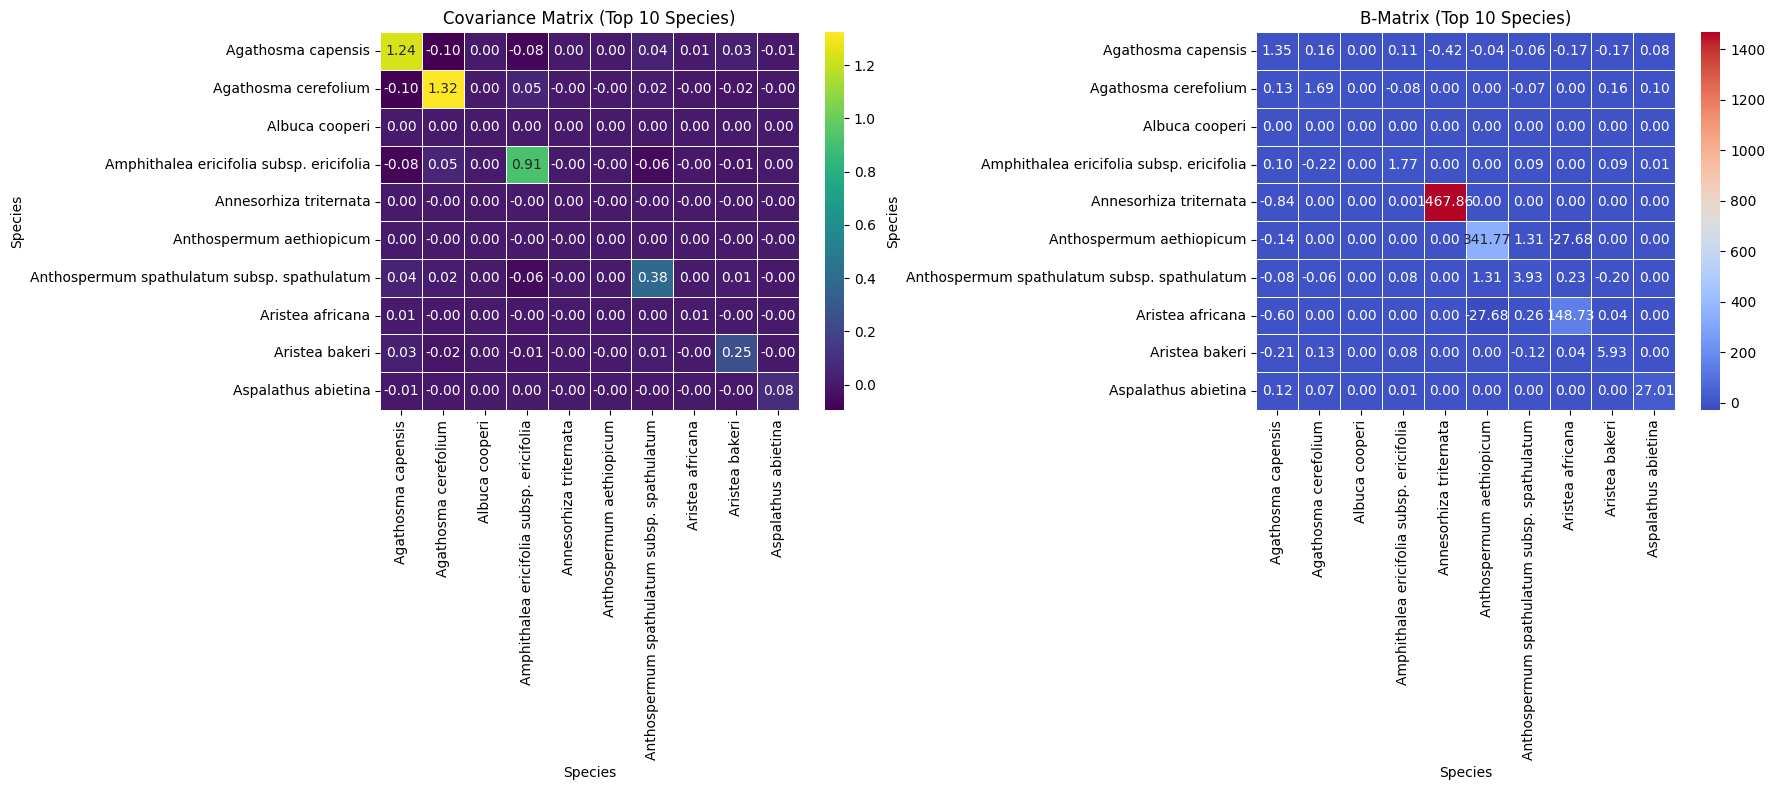

In [21]:

species_names = site_species_matrix_train.columns
top_10_species = species_names[0:10]

# Extract the sub-covariance matrix for these top 10 species
top_10_covariance_matrix_train = species_covariance_matrix_train.loc[top_10_species, top_10_species]

# Extract the corresponding sub-B matrix
top_10_b_matrix_train = b_matrix_train.loc[top_10_species, top_10_species]

# Set up the matplotlib figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot the Covariance Matrix
sns.heatmap(top_10_covariance_matrix_train, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Covariance Matrix (Top 10 Species)')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Species')

# Plot the B-Matrix
sns.heatmap(top_10_b_matrix_train, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('B-Matrix (Top 10 Species)')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Species')

plt.tight_layout()
plt.show()

Now that `b_matrix_train` is generated using the training data, we will use it with the test set to estimate species abundances.

### Visualizing Covariance and B-Matrix

To understand the relationships captured by the covariance and the derived `b_matrix` (which represents direct species interactions in our model), let's visualize these matrices for a smaller, more manageable subset of species. We'll select the top 10 most abundant species from our `final_abundance_estimates`.

Spearman(abundance, affected-by-others) = -0.815, p = 3.23e-18


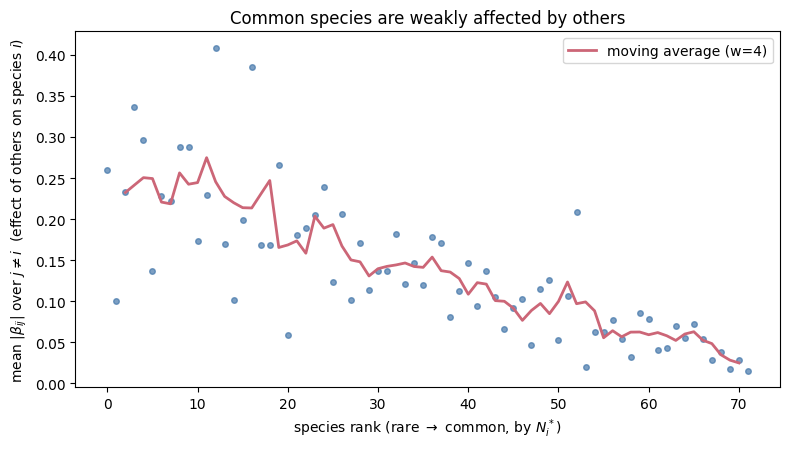

In [23]:
# Restrict to well-sampled species (same threshold as elsewhere)
N_star_series = site_species_matrix_train.sum(axis=0)/len(site_species_matrix_train)
min_sites = 20
occurrence = (site_species_matrix_train > 0).sum(axis=0)
keep = occurrence[occurrence >= min_sites].index
B = b_matrix_train.loc[keep, keep]
N_star = N_star_series[keep]          # equilibrium abundances for kept species

# "Affected by others" = mean ABSOLUTE off-diagonal in each ROW
Boff = B.values.copy()
np.fill_diagonal(Boff, 0.0)
affected = np.abs(Boff).sum(axis=1) / (len(B) - 1)   # mean |effect of others on i|

# Rank by abundance (rare -> common)
order = np.argsort(N_star.values)
rank = np.arange(len(order))
affected_sorted = affected[order]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(rank, affected_sorted, 'o', ms=4, color='#4477AA', alpha=0.7)
# optional smoothing to show the trend
from numpy import convolve, ones
w = max(3, len(rank)//15)
smooth = convolve(affected_sorted, ones(w)/w, mode='valid')
ax.plot(np.arange(len(smooth)) + w//2, smooth, '-', color='#CC6677', lw=2,
        label=f'moving average (w={w})')
ax.set_xlabel('species rank (rare $\\rightarrow$ common, by $N_i^*$)')
ax.set_ylabel(r'mean $|{\beta_{ij}}|$ over $j\neq i$  (effect of others on species $i$)')
ax.set_title('Common species are weakly affected by others')
ax.legend()
plt.tight_layout()
plt.savefig('affected_vs_rank.png', dpi=150, bbox_inches='tight')

# quantify the trend
from scipy.stats import spearmanr
rho, p = spearmanr(N_star.values, affected)
print(f"Spearman(abundance, affected-by-others) = {rho:.3f}, p = {p:.2e}")

In [24]:

def audit_sites(B, sites, N_star, tol=1e-10):
    """
    For each site, build the sub-community LCP and record:
      - whether the sub-community is STABLE (J_SS = diag(N*_S) B_SS positive-definite)
      - whether Lemke returns a SOLUTION, a SECONDARY RAY (None), or ERRORED.

    B      : (S x S) DataFrame, species-indexed interaction matrix.
    sites  : (m x S) DataFrame, rows = sites, cols = species, abundances (0 = absent).
    N_star : Series of equilibrium abundances (species-indexed), from train set.
    """
    records = []
    for site_id, row in sites.iterrows():
        species = row[row > 0].index.tolist()
        S = len(species)
        if S == 0:
            print("site: ",site_id, " has 0 species. ")
            records.append((site_id, 0, None, "empty")); continue

        B_SS = B.loc[species, species].values
        N_SS = N_star.reindex(species).values

        # stability: PD of J_SS = diag(N*_S) B_SS
        if np.any(~np.isfinite(N_SS)) or np.any(N_SS < 0):
            print("site : ",site_id, " has: ", N_SS)
            stable = None
        else:
            J_SS = np.diag(N_SS) @ B_SS
            eig = np.linalg.eigvalsh(0.5 * (J_SS + J_SS.T))   # symmetrize, real eigenvalues
            stable = bool(np.all(eig > tol))

        # Lemke on LCP(-1, B_SS)
        q = -np.ones(S)
        try:
            z = lemke_lcp(B_SS, q, tol=tol)
            outcome = "secondary_ray" if z is None else "solution"
        except Exception as e:
            outcome = f"error:{type(e).__name__}"

        records.append((site_id, S, stable, outcome))

    df = pd.DataFrame(records, columns=["site_id", "n_species", "stable", "lemke_outcome"])

    total = len(df)
    print(f"Total sites: {total}\n")
    print("Stability (J_SS positive-definite):")
    print(f"  stable      : {(df.stable == True).sum()}")
    print(f"  unstable    : {(df.stable == False).sum()}")
    print(f"  unassessable: {df.stable.isna().sum()}  (empty / missing N*)\n")
    print("Lemke outcome:")
    print(f"  solution found : {(df.lemke_outcome == 'solution').sum()}")
    print(f"  secondary ray  : {(df.lemke_outcome == 'secondary_ray').sum()}")
    other = df[~df.lemke_outcome.isin(['solution', 'secondary_ray'])]
    print(f"  other/errors   : {len(other)}")
    print("\nCross-tab (stability vs Lemke outcome):")
    print(pd.crosstab(df.stable, df.lemke_outcome, dropna=False))
    return df
valid = N_star_series.dropna().index                       # species with real N*
sites_clean = site_species_matrix_test[site_species_matrix_test.columns.intersection(valid)]
B_clean = b_matrix_train.loc[valid, valid]
# audit on sites_clean, B_clean, N_star.loc[valid]
print("dropped species: ", len(N_star_series) - len(valid))
site_statuses = audit_sites(B_clean, sites_clean, N_star_series)
ray_sites = site_statuses[site_statuses.lemke_outcome == "secondary_ray"]
print(f"{len(ray_sites)} sites returned a secondary ray:\n")
print(ray_sites.to_string(index=False))

dropped species:  0
Total sites: 750

Stability (J_SS positive-definite):
  stable      : 660
  unstable    : 90
  unassessable: 0  (empty / missing N*)

Lemke outcome:
  solution found : 740
  secondary ray  : 10
  other/errors   : 0

Cross-tab (stability vs Lemke outcome):
lemke_outcome  secondary_ray  solution
stable                                
False                     10        80
True                       0       660
10 sites returned a secondary ray:

site_id  n_species  stable lemke_outcome
 Y03X29         15   False secondary_ray
 Y03X36         19   False secondary_ray
 Y04X36         12   False secondary_ray
 Y14X44         13   False secondary_ray
 Y21X37         13   False secondary_ray
 Y31X26         15   False secondary_ray
 Y37X48         15   False secondary_ray
 Y40X22         14   False secondary_ray
 Y41X09         11   False secondary_ray
 Y50X50         12   False secondary_ray


Excluded 59 rare species (< 2 sites); 118 retained.


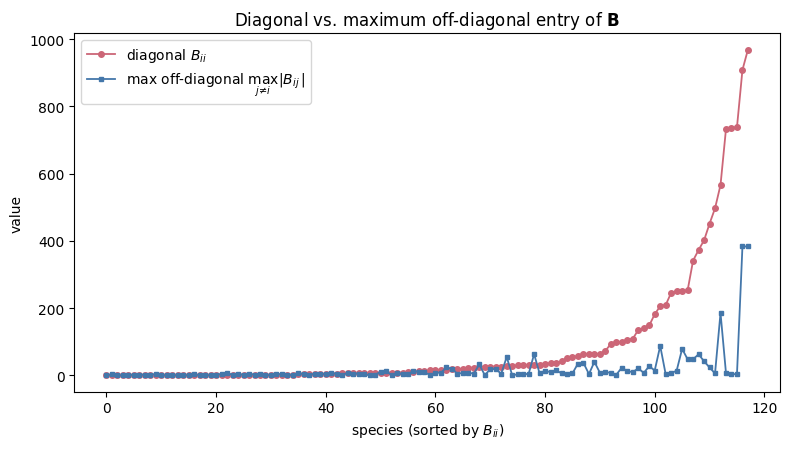

In [26]:


B_full = b_matrix_train                             # pandas DataFrame, species-indexed

# --- Identify rare species by OCCURRENCE (the principled criterion) ---
occurrence = (site_species_matrix_train > 0).sum(axis=0)   # sites each species occurs in
min_sites = 2                                  # threshold: set deliberately, see notes
rare = occurrence[occurrence < min_sites].index
keep_species = [s for s in B_full.index if s not in rare]

# --- Drop rare species from BOTH rows and columns (principal submatrix) ---
B = B_full.loc[keep_species, keep_species].values

print(f"Excluded {len(rare)} rare species (< {min_sites} sites); "
      f"{len(keep_species)} retained.")

# --- Diagonal vs max off-diagonal on the cleaned matrix ---
dia = np.diag(B)
Boff = B.copy(); np.fill_diagonal(Boff, 0)
max_off = np.abs(Boff).max(axis=1)

order = np.argsort(dia)
x = np.arange(len(dia))

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(x, dia[order], 'o-', color='#CC6677', ms=4, lw=1.3,
        label=r'diagonal $B_{ii}$')
ax.plot(x, max_off[order], 's-', color='#4477AA', ms=3, lw=1.3,
        label=r'max off-diagonal $\max_{j\neq i}|B_{ij}|$')
ax.set_xlabel('species (sorted by $B_{ii}$)')
ax.set_ylabel('value')
ax.set_title('Diagonal vs. maximum off-diagonal entry of $\\mathbf{B}$')
ax.legend()
plt.tight_layout()
plt.savefig('B_diag_dominance.png', dpi=150, bbox_inches='tight')

# Site Stability Analysis

We eliminate very rare species as their data is too minimal to draw a conclusion.
Then we check among the unstable sites which species is most common in the unstable direction

In [27]:
# Count site occurrences for each species (number of sites where abundance > 0)
site_counts = (site_species_matrix_train > 0).sum(axis=0)   # axis depends on your matrix orientation

min_sites = 20  # or your previously chosen value
keep = site_counts >= min_sites
print(f"Keeping {keep.sum()} of {len(keep)} species (min_sites = {min_sites})")

# Take principal submatrix — drop from BOTH rows and columns
B_reduced = b_matrix_train.loc[keep[keep].index, keep[keep].index]

# Re-run the diagonal-dominance check on the reduced matrix
dia = np.diag(B_reduced.values)
Boff = B_reduced.values.copy(); np.fill_diagonal(Boff, 0)
max_off = np.abs(Boff).max(axis=1)
order = np.argsort(dia)

count = 0
for i in order:
    if dia[i] < max_off[i]:
        print(B_reduced.index[i], dia[i], max_off[i])
        count += 1

print(f"\n{count} crossings out of {len(order)} species")

Keeping 72 of 177 species (min_sites = 20)
Erica imbricata 0.1301137331852216 0.1905770707926617
Rafnia acuminata 0.44849758225371955 0.8078679981037085
Restio sieberi 0.8480077080975994 0.9302943204235992
Hypodiscus aristatus 0.8974312757793367 1.1004765402771894
Tetraria bromoides 3.863806514913893 4.851727327293509

5 crossings out of 72 species


In [28]:


B = b_matrix_train  # DataFrame indexed by species; assumes already restricted to kept species

focal = ["Erica imbricata", "Rafnia acuminata", "Restio sieberi",
         "Hypodiscus aristatus", "Tetraria bromoides"]

for sp in focal:
    row = B.loc[sp].drop(sp)                    # effects of all OTHER species on sp (B[sp, j])
    j_star = row.abs().idxmax()                 # strongest |interaction|
    val = row[j_star]
    print(f"{sp:<22} strongest interactor: {j_star:<22} "
          f"B[{sp},{j_star}] = {val:+.3f}")

Erica imbricata        strongest interactor: Brabejum stellatifolium B[Erica imbricata,Brabejum stellatifolium] = +0.463
Rafnia acuminata       strongest interactor: Hypodiscus aristatus   B[Rafnia acuminata,Hypodiscus aristatus] = +0.808
Restio sieberi         strongest interactor: Leucospermum conocarpodendron subsp. viridum B[Restio sieberi,Leucospermum conocarpodendron subsp. viridum] = +2.969
Hypodiscus aristatus   strongest interactor: Gnidia pinifolia       B[Hypodiscus aristatus,Gnidia pinifolia] = -1.100
Tetraria bromoides     strongest interactor: Cassytha ciliolata     B[Tetraria bromoides,Cassytha ciliolata] = -4.852


In [29]:


# --- Define rare species by occurrence in the training set ---
occurrence = (site_species_matrix_train > 0).sum(axis=0)
rare_species = occurrence[occurrence < min_sites].index.tolist()
retained = [s for s in B.index if s not in rare_species]

print(f"Excluding {len(rare_species)} rare species (< {min_sites} sites); "
      f"{len(retained)} retained.")

# --- Restrict B and N* to retained species (principal submatrix) ---
B_clean = B.loc[retained, retained]
N_star_clean = N_star.loc[retained]

# --- Restrict the sites to retained species too ---
# (drop the rare-species columns; a site's present-set is now only retained species)
sites_clean = site_species_matrix_test[[c for c in site_species_matrix_test.columns if c in retained]]

# --- Re-run the audit on the cleaned data ---
df_clean = audit_sites(B_clean, sites_clean, N_star_clean)

Excluding 105 rare species (< 20 sites); 72 retained.
Total sites: 750

Stability (J_SS positive-definite):
  stable      : 688
  unstable    : 62
  unassessable: 0  (empty / missing N*)

Lemke outcome:
  solution found : 750
  secondary ray  : 0
  other/errors   : 0

Cross-tab (stability vs Lemke outcome):
lemke_outcome  solution
stable                 
False                62
True                688


In [31]:


# training occurrence counts (sites each species appears in)
occurrence = (site_species_matrix_train > 0).sum(axis=0)

# unstable sites from the audit
unstable_ids = site_statuses[site_statuses.stable == False].site_id
sites_with_rare = 0
summary = []
for site_id in unstable_ids:
    row = sites_clean.loc[site_id]
    species = row[row > 0].index.tolist()
    N_SS = N_star.reindex(species)

    # per-species detail
    detail = pd.DataFrame({
        "N_star": N_SS.values,
        "occurrence": [occurrence.get(s, np.nan) for s in species],
    }, index=species).sort_values("N_star")

    # site-level summary numbers
    n_sp        = len(species)
    total_Nstar = np.nansum(N_SS.values)
    min_Nstar   = np.nanmin(N_SS.values)
    n_rare      = int((detail["occurrence"] < min_sites).sum())   # how many are "rare"
    n_nan       = int(N_SS.isna().sum())

    if n_rare > 0 or n_nan > 0:
      sites_with_rare += 1

    summary.append({
        "site_id": site_id, "n_species": n_sp,
        "total_Nstar": total_Nstar, "min_Nstar": min_Nstar,
        "n_rare_species": n_rare, "n_nan_Nstar": n_nan,
    })

    # print per-site detail
    print(f"\n=== Unstable site {site_id} | {n_sp} species | "
          f"total N* = {total_Nstar:.3f} | {n_rare} rare | {n_nan} NaN ===")
    print(detail.to_string())

# overall summary table across unstable sites
summary_df = pd.DataFrame(summary)
print("\n\n=== Summary across unstable sites ===")
print(summary_df.to_string(index=False))
print(sites_with_rare)


=== Unstable site Y01X09 | 19 species | total N* = 24.891 | 0 rare | 0 NaN ===
                                   N_star  occurrence
Thesium euphrasioides            0.108571         146
Centella glabrata var. glabrata  0.117714         154
Prismatocarpus diffusus          0.280571         230
Schoenus compar                  0.343429         201
Hypodiscus aristatus             0.460571         202
Restio triticeus                 0.484000         489
Restio sieberi                   0.762857         473
Schoenus pseudoloreus            0.937714         537
Restio sporadicus                1.065143         621
Restio capensis                  1.180571         907
Rafnia acuminata                 1.190857         414
Myrovernix gnaphaloides          1.281714         704
Pentameris pallida               1.622857        1173
Schoenus exilis                  1.724000        1194
Thamnochortus guthrieae          1.984000        1273
Tetraria ustulata                2.321143         830
La

In [32]:


occurrence = (site_species_matrix_train > 0).sum(axis=0)
rows = []
for site_id in df_clean[df_clean.stable == False].site_id:
    sp = sites_clean.loc[site_id][sites_clean.loc[site_id] > 0].index.tolist()
    N_SS = N_star_clean.reindex(sp).values
    J = np.diag(N_SS) @ B_clean.loc[sp, sp].values
    eig = np.linalg.eigvalsh(0.5*(J + J.T))
    v = np.linalg.eigh(0.5*(J+J.T))[1][:, 0]      # most-negative eigenvector
    dominant_sp = sp[np.argmax(v**2)]              # species dominating instability
    rows.append({
        "site_id": site_id, "n_species": len(sp),
        "min_eig": eig.min(),
        "n_negative": int((eig < -1e-10).sum()),
        "dominant_species": dominant_sp,
        "cond": np.abs(eig).max()/max(np.abs(eig).min(), 1e-300),
    })
resid = pd.DataFrame(rows)

print("Residual unstable sites (after rare-species exclusion):", len(resid))
print(f"\nSmallest eigenvalue distribution:")
print(f"  near zero (> -1e-6):   {(resid.min_eig > -1e-6).sum()}")
print(f"  mildly negative:       {((resid.min_eig <= -1e-6) & (resid.min_eig > -0.1)).sum()}")
print(f"  robustly negative:     {(resid.min_eig <= -0.1).sum()}")
print(f"\nMost common 'dominant' species in the unstable direction:")
print(resid.dominant_species.value_counts().head(10))
print(f"\nMedian condition number: {resid.cond.median():.2e}")

Residual unstable sites (after rare-species exclusion): 62

Smallest eigenvalue distribution:
  near zero (> -1e-6):   0
  mildly negative:       46
  robustly negative:     16

Most common 'dominant' species in the unstable direction:
dominant_species
Erica imbricata            45
Hypodiscus aristatus        5
Gnidia pinifolia            4
Protea laurifolia           2
Montinia caryophyllacea     2
Tetraria bromoides          2
Cassytha ciliolata          2
Name: count, dtype: int64

Median condition number: 3.51e+01


In [33]:
#Next we see the impact of removing this species
retained2 = [s for s in retained if s != "Erica imbricata"]
B2 = B_clean.loc[retained2, retained2]
sites2 = sites_clean[[c for c in sites_clean.columns if c in retained2]]
df2 = audit_sites(B2, sites2, N_star_clean.loc[retained2])
print(f"Unstable after also removing Erica imbricata: {(df2.stable==False).sum()}")

Total sites: 750

Stability (J_SS positive-definite):
  stable      : 738
  unstable    : 12
  unassessable: 0  (empty / missing N*)

Lemke outcome:
  solution found : 750
  secondary ray  : 0
  other/errors   : 0

Cross-tab (stability vs Lemke outcome):
lemke_outcome  solution
stable                 
False                12
True                738
Unstable after also removing Erica imbricata: 12


### Visualizing Discrepancies: Estimated vs. Actual Abundance on Test Set

To visually inspect the agreement between the estimated abundances and the actual abundances in the test set, we can create a scatter plot. A diagonal line (y=x) will represent perfect prediction, allowing us to see how closely our estimates align with the true values.

Finally, we will compare the estimated abundances on the test set (`final_abundance_estimates_test`) with the actual column sums of species from the `site_species_matrix_test`.

### Average Variance for All Species (Training Data)

To understand the overall variability of species abundances in our training dataset, we can calculate the average of the diagonal elements of the `species_covariance_matrix_train`. These diagonal elements represent the variance of each individual species' abundance.

In [30]:
# Estimate abundances on the test set using b_matrix_train
print("\nStarting abundance estimation on TEST SET...")
final_abundance_estimates_test = EstimateAbundance(sites_clean, B_clean,N_star_clean)

print("\nFinal estimated abundances on Test Set (head):")
display(final_abundance_estimates_test)


Starting abundance estimation on TEST SET...
Lemke succeeded: 750/750;  fallback: 0

Final estimated abundances on Test Set (head):


(Species
 Agathosma capensis                              218.540860
 Agathosma cerefolium                             60.656417
 Amphithalea ericifolia subsp. ericifolia        133.240270
 Anthospermum spathulatum subsp. spathulatum      52.749674
 Aristea bakeri                                   10.842935
                                                   ...     
 Thesium euphrasioides                            15.990011
 Thesium virgatum                                  0.315271
 Tribolium uniolae                                 1.747954
 Wahlenbergia subulata var. subulata              11.790706
 Willdenowia glomerata                          1122.093154
 Length: 72, dtype: float64,
 [('Y01X09',
   Centella glabrata var. glabrata     0.449071
   Erica imbricata                    11.106117
   Hypodiscus aristatus                1.759796
   Lanaria lanata                      0.000000
   Myrovernix gnaphaloides             4.280596
   Pentameris pallida                  0.240111
 

In [34]:
print(f"occurrence:  {occurrence['Erica imbricata']}")
print(f"N*:          {N_star_clean['Erica imbricata']:.4f}")
print(f"diagonal:    {B_clean.loc['Erica imbricata','Erica imbricata']:.4f}")
erica = site_species_matrix_train['Erica imbricata']
print(f"observed:    mean={erica[erica>0].mean():.2f}, sites={(erica>0).sum()}, total={erica.sum():.0f}")

occurrence:  1008
N*:          3.3549
diagonal:    0.1301
observed:    mean=5.82, sites=1008, total=5871


In [37]:
total_abundance, per_site, fallback_sites = EstimateAbundance(
    sites_clean, B_clean, N_star_series)

sq_resid_sum = 0.0
n_resid = 0
per_site_norm = []

for site_id, pred in per_site:
    if site_id in fallback_sites:        # exclude fallback sites from model evaluation
        continue
    sp = sites_clean.loc[site_id]
    sp = sp[sp > 0]
    actual = sp                                  # actual abundances, indexed by species
    pred_aligned = pred.reindex(actual.index)    # align predicted to same species/order
    resid = (actual - pred_aligned).values

    sq_resid_sum += np.nansum(resid**2)          # accumulate squared residuals
    n_resid += np.sum(~np.isnan(resid))
    per_site_norm.append(np.linalg.norm(resid[~np.isnan(resid)]))

rmse = np.sqrt(sq_resid_sum / n_resid)
print(f"RMSE over all (site,species) residuals: {rmse:.4f}")
print(f"Mean per-site error norm: {np.mean(per_site_norm):.4f}")
print(f"(evaluated on {len(per_site_norm)} LCP-solved sites; "
      f"{len(fallback_sites)} fallback sites excluded)")

Lemke succeeded: 750/750;  fallback: 0
RMSE over all (site,species) residuals: 3.3905
Mean per-site error norm: 10.6318
(evaluated on 750 LCP-solved sites; 0 fallback sites excluded)


In [39]:


def evaluate(per_site, test, predictor_name, baseline_means=None, fallback=()):
    """
    baseline_means=None  -> evaluate the model's per_site predictions
    baseline_means given -> predict each site with the per-species mean
    Reports absolute RMSE and mean per-site relative (composition) error.
    """
    sq,  rel_errs = [], []
    for site_id, pred in per_site:
        if site_id in fallback:
            continue
        actual = test.loc[site_id]; actual = actual[actual > 0]
        species = actual.index

        p = pred.reindex(species) if baseline_means is None else baseline_means.reindex(species)

        resid = (actual - p).values
        sq.append(np.sqrt(np.nansum(resid**2)/np.sum(~np.isnan(resid))))

        # composition error: total-variation distance between proportion vectors
        a_prop = actual.values / actual.values.sum()
        p_prop = p.values / np.nansum(p.values)
        rel_errs.append(np.nansum(np.abs(a_prop - p_prop)) / 2)

    rmse, rel = np.mean(sq), np.mean(rel_errs)
    print(f"{predictor_name:<22} RMSE(abs)={rmse:8.4f}   mean composition error={rel:.4f}")
    return rmse, rel

total_abundance, per_site, fallback_sites = EstimateAbundance(
    sites_clean, b_matrix_train, N_star_series)

print("Per-site evaluation (fallback sites excluded):\n")
evaluate(per_site, sites_clean, "MODEL (LCP)", None, fallback_sites)
evaluate(per_site, sites_clean, "BASELINE (per-species mean)", N_star_series, fallback_sites)

Lemke succeeded: 750/750;  fallback: 0
Per-site evaluation (fallback sites excluded):

MODEL (LCP)            RMSE(abs)=  3.0119   mean composition error=0.3189
BASELINE (per-species mean) RMSE(abs)=  3.0787   mean composition error=0.3182


(np.float64(3.078663159734934), np.float64(0.3182476651717176))

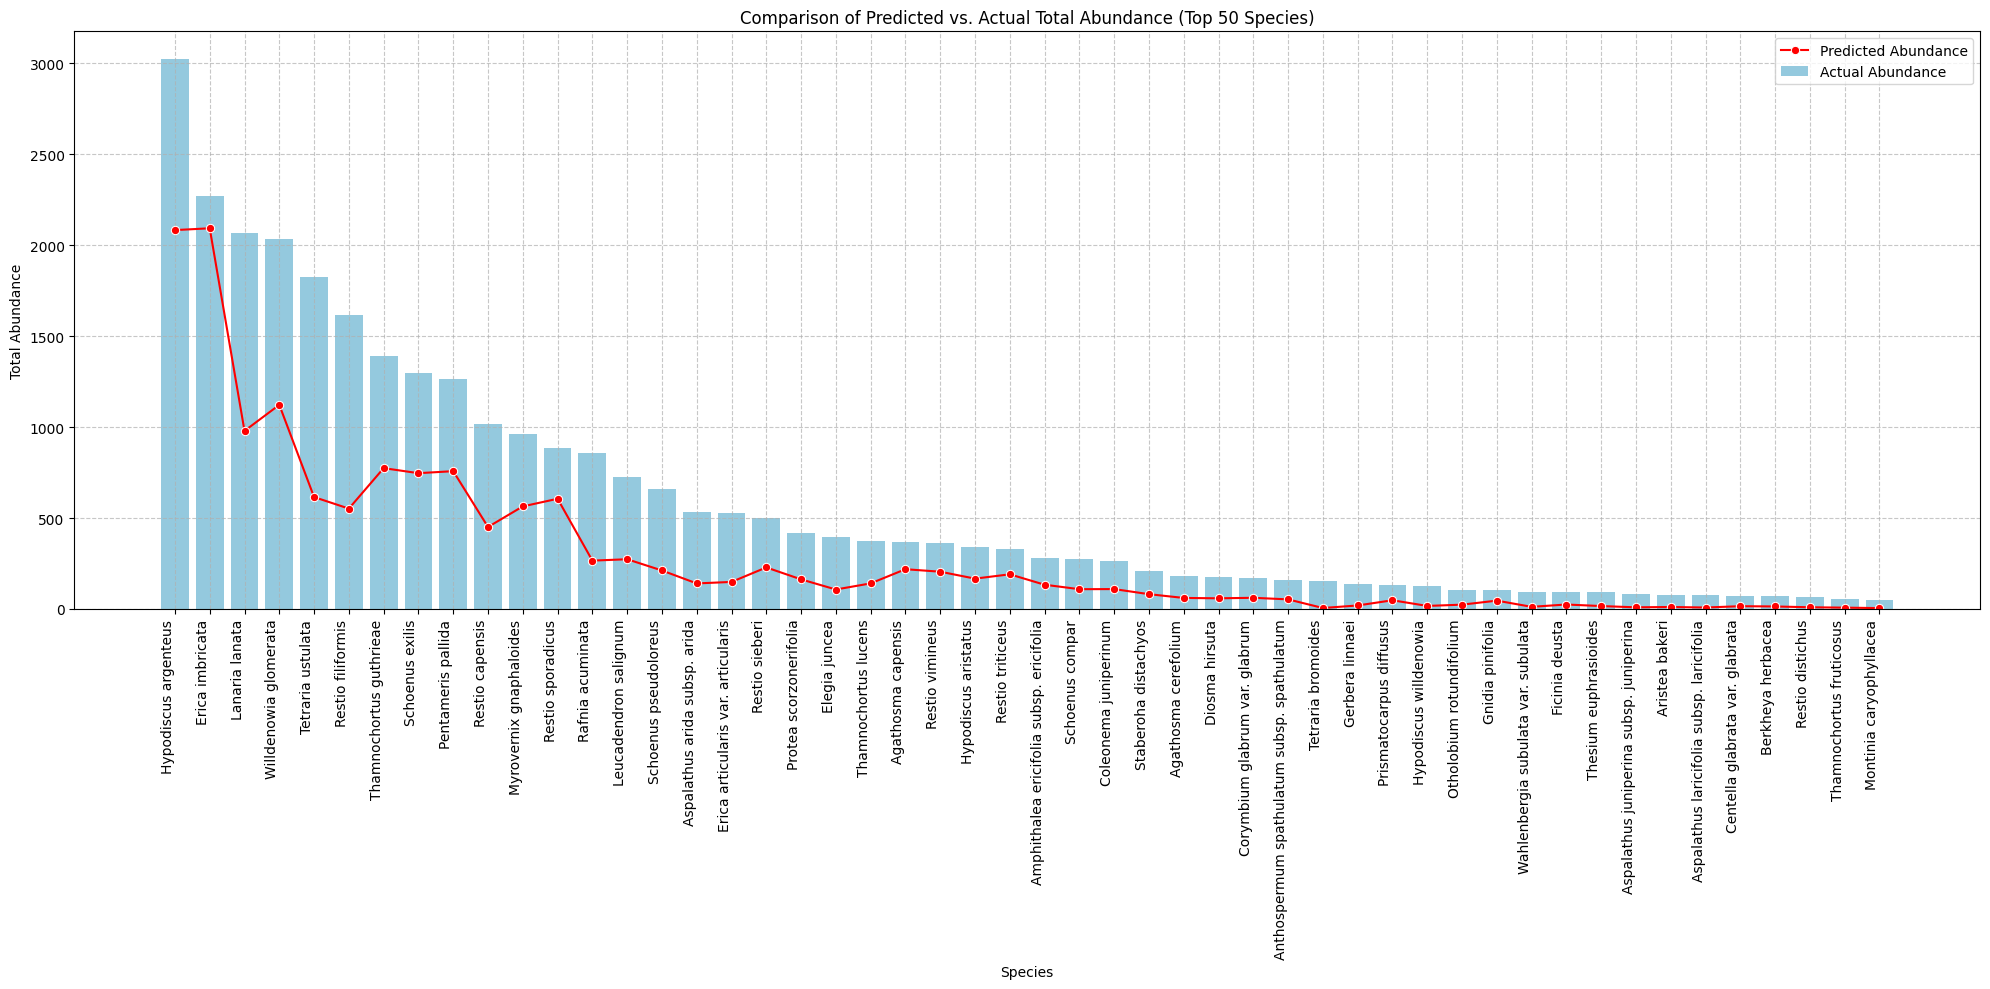

In [40]:


# Calculate actual abundance from the test set
actual_test_set_abundance = sites_clean.sum(axis=0)

# Ensure both series have the same index for alignment
combined_abundance = pd.DataFrame({
    'Actual Abundance': actual_test_set_abundance,
    'Predicted Abundance': total_abundance
}).fillna(0)

# Sort by actual abundance for better visualization
combined_abundance = combined_abundance.sort_values(by='Actual Abundance', ascending=False)

# Select top N species for clarity, if desired, otherwise plot all
top_n = 50  # Adjust as needed
combined_abundance_top = combined_abundance.head(top_n)

plt.figure(figsize=(20, 10))

# Plot Actual Abundance as a Bar Chart
sns.barplot(x=combined_abundance_top.index, y='Actual Abundance', data=combined_abundance_top, color='skyblue', label='Actual Abundance')

# Plot Predicted Abundance as a Line Chart on the same axes
sns.lineplot(x=combined_abundance_top.index, y='Predicted Abundance', data=combined_abundance_top, color='red', marker='o', label='Predicted Abundance')

plt.xlabel('Species')
plt.ylabel('Total Abundance')
plt.title(f'Comparison of Predicted vs. Actual Total Abundance (Top {top_n} Species)')
plt.xticks(rotation=90, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:


# Filter out species where both estimated and actual are zero for clearer correlation calculation
non_zero_combined_abundance = combined_abundance[(combined_abundance['Actual Abundance'] != 0) | (combined_abundance['Predicted Abundance'] != 0)]

if not non_zero_combined_abundance.empty:
    correlation, _ = pearsonr(non_zero_combined_abundance['Predicted Abundance'], non_zero_combined_abundance['Actual Abundance'])
    print(f"Pearson correlation between predicted and actual total abundances: {correlation:.4f}")
else:
    print("No non-zero species to calculate correlation.")

Pearson correlation between predicted and actual total abundances: 0.9449
